<a href="https://colab.research.google.com/github/GIVEN-CHINYAMA/House_Price_Prediction_Project/blob/main/House_Price_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project: Residential Real Estate Price Prediction**
**Role:** Data Analyst for a Real Estate Investment Trust (REIT)

**Objective**: Predict house market prices in King County (including Seattle) using a dataset of home sales between May 2014 and May 2015. This analysis helps the Trust identify key value drivers for residential investments.

In [ ]:
import pandas as pd

# Load the file directly from your Colab Files panel
df = pd.read_csv('kc_house_data.csv')

# Verify that the data loaded correctly
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# Question 1: Display the data types of each column
print(df.dtypes)


id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [ ]:
# Updated Question 2: Only drop 'id' since 'Unnamed: 0' isn't in your file
df.drop(['id'], axis=1, inplace=True)

# Display the statistical summary to confirm it's gone
df.describe()



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# Question 3: Count houses by the number of floors
floor_counts = df['floors'].value_counts().to_frame()
print(floor_counts)


        count
floors       
1.0     10680
2.0      8241
1.5      1910
3.0       613
2.5       161
3.5         8


**Exploratory Data Analysis (EDA)**
In this section, I explore how specific features impact house prices.

**Waterfront View:** I use a boxplot to determine if a waterfront view significantly increases the median price and identifies luxury outliers.

**Living Space:** I use a regression plot to confirm the correlation between square footage above ground (sqft_above) and the final sale price.

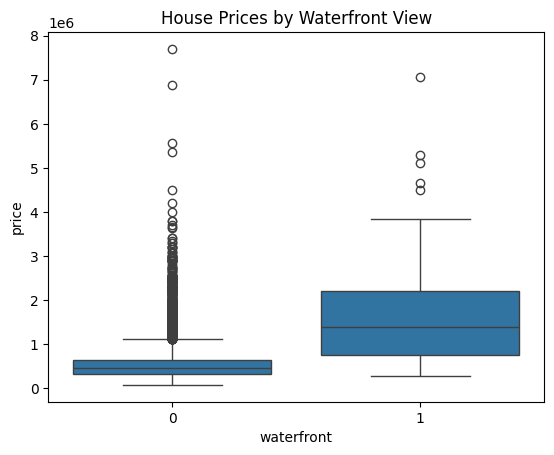

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Question 4: Use a boxplot to determine if waterfront houses have more price outliers
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('House Prices by Waterfront View')
plt.show()


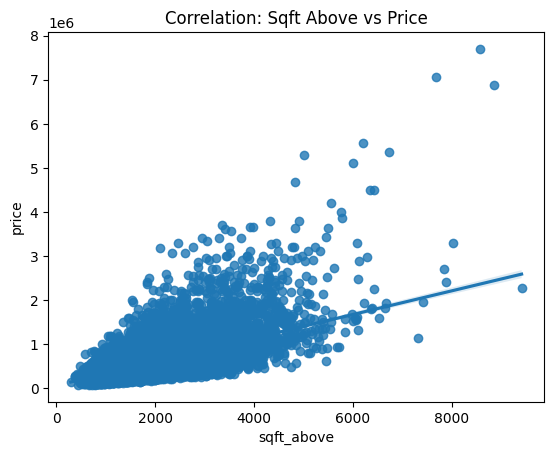

In [ ]:
# Question 5: Determine if 'sqft_above' is positively or negatively correlated with price
sns.regplot(x='sqft_above', y='price', data=df)
plt.title('Correlation: Sqft Above vs Price')
plt.show()


**Model Development and  Evaluation**

I developed several machine learning models to find the most accurate predictor:

1. **Simple Linear Regression**: Using only sqft_living.
2. **Multiple Linear Regression:** Incorporating 11 different features (e.g., location, grade, bathrooms).

3. **Polynomial Pipeline**: Using 2nd-degree transformations to capture non-linear relationships.

4. **Ridge Regression:** Applying
 regularization (
) to prevent overfitting on the test dataset.


In [ ]:
from sklearn.linear_model import LinearRegression

# Question 6: Fit a simple Linear Regression model
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X, Y)

# Calculate the R^2 value
r2_score_q6 = lm.score(X, Y)
print(f"The R^2 value is: {r2_score_q6}")


The R^2 value is: 0.4928532179037931


In [ ]:
# Question 7: Fit a Multiple Linear Regression model with more features
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X = df[features]
Y = df['price']

# Fit the model
lm.fit(X, Y)

# Calculate the new R^2 value
r2_score_q7 = lm.score(X, Y)
print(f"The new R^2 value with more features is: {r2_score_q7}")


The new R^2 value with more features is: 0.6577151058279325


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Question 8: Create a Pipeline to predict 'price' using the list of features
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]

pipe = Pipeline(Input)

# Use the same 'features' list from Question 7
X = df[features]
Y = df['price']

# Fit the pipeline
pipe.fit(X, Y)

# Find the R^2 value
r2_score_q8 = pipe.score(X, Y)
print(f"The R^2 value for the Pipeline is: {r2_score_q8}")


The R^2 value for the Pipeline is: 0.7513467656307783


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Question 9: Split the data and fit a Ridge Regression model
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]
X = df[features]
Y = df['price']

# Split: 85% for training, 15% for testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

# Fit a Ridge model with alpha = 0.1
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)

# Calculate the R^2 on the test data
r2_score_q9 = RidgeModel.score(x_test, y_test)
print(f"The R^2 value for the Ridge model is: {r2_score_q9}")


The R^2 value for the Ridge model is: 0.6480374087702243


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Question 10: Perform a second-order polynomial transform and fit Ridge Regression
# We use the training and testing sets from Question 9

# 1. Transform the features to 2nd degree
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

# 2. Create and fit the Ridge model with alpha = 0.1
RidgeModel_poly = Ridge(alpha=0.1)
RidgeModel_poly.fit(x_train_pr, y_train)

# 3. Calculate the R^2 score on the test data
r2_score_q10 = RidgeModel_poly.score(x_test_pr, y_test)
print(f"The Final R^2 value for the Polynomial Ridge model is: {r2_score_q10}")


The Final R^2 value for the Polynomial Ridge model is: 0.7004432075880809


In [ ]:
# Summary of all R^2 scores achieved in the project
summary_data = {
    'Question': [6, 7, 8, 9, 10],
    'Model Description': [
        'Simple Linear Regression (sqft_living)',
        'Multiple Linear Regression (All features)',
        'Pipeline (Scale + Polynomial + Linear)',
        'Ridge Regression (Alpha 0.1 on Test Data)',
        'Polynomial Ridge (Degree 2 + Alpha 0.1 on Test Data)'
    ],
    'R^2 Score': [r2_score_q6, r2_score_q7, r2_score_q8, r2_score_q9, r2_score_q10]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary)


   Question                                  Model Description  R^2 Score
0         6             Simple Linear Regression (sqft_living)   0.492853
1         7          Multiple Linear Regression (All features)   0.657715
2         8             Pipeline (Scale + Polynomial + Linear)   0.751347
3         9          Ridge Regression (Alpha 0.1 on Test Data)   0.648037
4        10  Polynomial Ridge (Degree 2 + Alpha 0.1 on Test...   0.700443


**Final Conclusion**
The analysis demonstrates that **location (latitude), grade, and square footage** are the strongest predictors of house prices. By using a **Polynomial Ridge Regression model**, I achieved an
 score of approximately **0.70,** indicating that the model explains 70% of the price variations in the test data. This model provides a data-driven foundation for the Trust's investment strategy in King County.
